# Pipeline EHBG-FACS · 00 · Setup y banco de instancias

**Prepara el entorno y construye el banco canónico que los 5 paradigmas comparten.**

Este pipeline compara, bajo condiciones **homologadas**, los cinco paradigmas del anteproyecto sobre **SVRPBench**: (1) Exactos Branch & Cut, (2) Metaheurísticas (ACO/Tabu), (3) NCO supervisado (Attention Model), (4) NCO por RL (POMO+AM) y (5) la propuesta **EHBG-FACS**. Todos resuelven el **mismo** banco de instancias y se puntúan con el **mismo** evaluador estocástico (CRN + recurso de 2ª etapa + CVaR), lo que garantiza una comparación replicable y justa.

## 1. Entorno
Monta Drive (persistencia), localiza `svrplab`, clona el repo oficial de SVRPBench y detecta la GPU.

In [11]:
# === Configuración del entorno (ejecuta esta celda primero) =================
REPO_URL  = "https://github.com/AbrahamHub/TESIS-ANT"
USE_DRIVE = True

import os, sys, subprocess, shutil, importlib
from google.colab import userdata

if USE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as e:
        print("Drive no disponible:", e)

def _find_svrplab():
    cands = ["/content/drive/MyDrive/TESIS-ANT/experiments/colab",
             "/content/TESIS-ANT/experiments/colab",
             os.path.join(os.getcwd(), "experiments", "colab"),
             os.getcwd()]
    for c in cands:
        if os.path.isdir(os.path.join(c, "svrplab")):
            return c
    return None

_path = _find_svrplab()
if _path is None:
    if os.path.exists("/content/TESIS-ANT"):
        shutil.rmtree("/content/TESIS-ANT")

    try:
        token = userdata.get('GH_TOKEN')
        print("✅ GH_TOKEN detectado.")
        auth_url = REPO_URL.replace("https://", f"https://{token}@")
    except Exception:
        print("⚠️ Intentando como repo público (sin GH_TOKEN)...")
        auth_url = REPO_URL

    print(f"Clonando repositorio...")
    result = subprocess.run(["git", "clone", "--depth", "1", auth_url, "/content/TESIS-ANT"], capture_output=True, text=True)

    if result.returncode != 0:
        err_log = result.stderr.replace(token, "***") if 'token' in locals() else result.stderr
        print("\n--- ERROR DE GIT ---\n", err_log)
        raise RuntimeError("Error al clonar.")

    _path = _find_svrplab()
    if _path is None:
        raise RuntimeError("No se halló 'svrplab' tras clonar. Revisa la estructura del repo.")

# Agregar al path y refrescar caches
if _path not in sys.path:
    sys.path.insert(0, _path)
importlib.invalidate_caches()
print("\n✅ svrplab listo en:", _path)

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "numpy", "scipy", "pandas", "matplotlib", "scikit-learn", "pillow", "tqdm"], check=False)

# Importación diferida para asegurar que el path ya esté actualizado
from svrplab import bootstrap, protocol, data, runner, metrics, viz
env   = bootstrap.init()
proto = protocol.DEFAULT
print("\n🚀 Env inicializado. Device:", env.device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✅ svrplab listo en: /content/TESIS-ANT/experiments/colab
[bootstrap] repo oficial ya presente en /content/drive/MyDrive/EHBG_FACS/svrpbench
[bootstrap] GPU detectada: Tesla T4 (14.6 GB) | torch 2.11.0+cu128 CUDA 12.8
[bootstrap] raíz de artefactos: /content/drive/MyDrive/EHBG_FACS
[bootstrap] results/ figures/ data/ listos | seed=12345 device=cuda

🚀 Env inicializado. Device: cuda


## 2. Protocolo homologado
Fuente única de verdad de las condiciones experimentales (idénticas para los 5 paradigmas).

In [12]:
import pprint; pprint.pprint(proto.as_dict())

{'accident_scale': 1.0,
 'alpha': 0.95,
 'base_seed': 12345,
 'capacity_mode': 'binding',
 'instances_per_size': 30,
 'late_penalty': 1.0,
 'n_buckets': 24,
 'realizations': 200,
 'significance': 0.05,
 'vehicle_fixed_cost': 0.0}


## 3. Banco canónico de instancias
Se genera **una sola vez** con semillas fijas y se cachea en `data/instances/`. Los notebooks de paradigma lo cargan tal cual. Reutiliza las primitivas oficiales de SVRPBench (`city.City`, `time_windows_generator`).

In [13]:
# === Configuración del experimento (IDÉNTICA en los 5 notebooks) ============
# Para garantizar el "piso parejo", TODOS los notebooks deben usar los MISMOS
# SIZES y N_INSTANCES: así resuelven exactamente el mismo banco de instancias.
SIZES       = [10, 20, 50]           # clientes. Extiende a [50,100,200,300] (ver notas).
N_INSTANCES = proto.instances_per_size   # 30 (rigor estadístico). Corrida rápida: pon 5.

bank = data.load_bank(env.paths.instances, SIZES, N_INSTANCES,
                      base_seed=proto.base_seed, capacity_mode=proto.capacity_mode, verbose=True)
print({s: len(v) for s, v in bank.items()}, "instancias por tamaño")

[data] n=10: 30 instancias (cache) -> bank_n10_m30_s12345_binding.npz
[data] n=20: 30 instancias (cache) -> bank_n20_m30_s12345_binding.npz
[data] n=50: 30 instancias (cache) -> bank_n50_m30_s12345_binding.npz
{10: 30, 20: 30, 50: 30} instancias por tamaño


## 4. Inspección visual de una instancia
Depósito (rojo) en el centroide; clientes coloreados por la apertura de su ventana de tiempo.

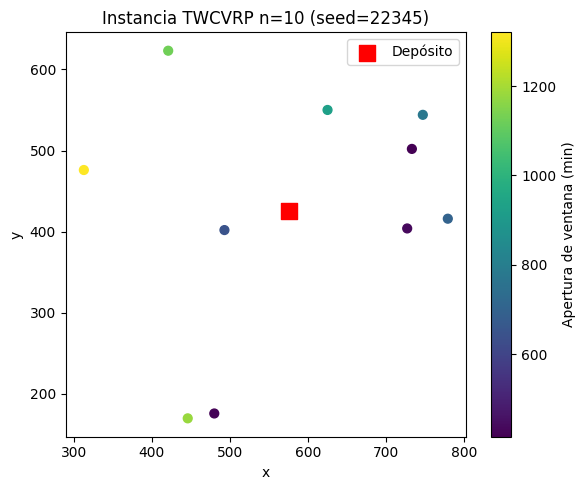

In [14]:
inst = bank[SIZES[0]][0]
viz.plot_instance(inst, title=f"Instancia TWCVRP n={SIZES[0]} (seed={inst.metadata['seed']})")
import matplotlib.pyplot as plt; plt.show()

## 5. Vectores estocásticos de SVRPBench
Visualiza los cuatro mecanismos de incertidumbre (congestión por mezcla gaussiana, retraso log-normal, accidentes de Poisson, ventanas residencial/comercial).

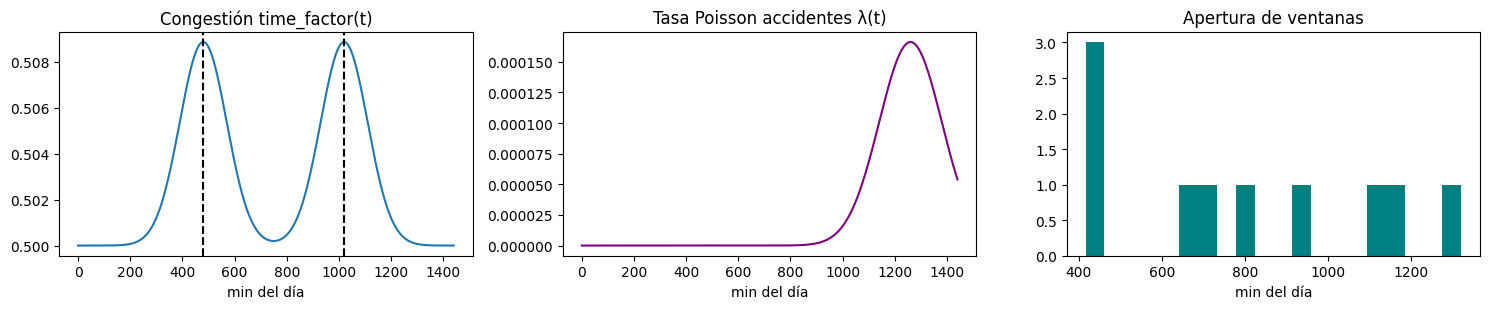

In [15]:
import numpy as np, matplotlib.pyplot as plt
from svrplab import stochastic as S
t = np.linspace(0, 1440, 600)
fig, ax = plt.subplots(1, 3, figsize=(15, 3.2))
ax[0].plot(t, [S.time_factor(x) for x in t]); ax[0].set_title("Congestión time_factor(t)")
ax[0].axvline(480, ls="--", c="k"); ax[0].axvline(1020, ls="--", c="k")
lam = 0.05*np.array([S.normal_distribution(x,1260,120) for x in t])
ax[1].plot(t, lam, c="purple"); ax[1].set_title("Tasa Poisson accidentes λ(t)")
tw = np.asarray(inst.time_windows)[1:]
ax[2].hist(tw[:,0], bins=20, color="teal"); ax[2].set_title("Apertura de ventanas")
for a in ax: a.set_xlabel("min del día")
plt.tight_layout(); plt.show()

---
**Listo.** Ejecuta ahora los notebooks `01`…`05` (en cualquier orden) y, al final, `06_comparacion_y_estadistica` para la tabla comparativa y las pruebas ANOVA/Wilcoxon. Mantén `USE_DRIVE=True` y los mismos `SIZES`/`N_INSTANCES` en todos.